In [1]:
import pandas as pd

In [2]:
X_train = pd.read_csv("../notebooks/X_train_resampled.csv")
y_train = pd.read_csv("../notebooks/y_train_resampled.csv").squeeze()

X_test = pd.read_csv("../notebooks/X_test.csv")
y_test = pd.read_csv("../notebooks/y_test.csv").squeeze()

In [3]:
print(X_train.shape)
print(y_train.value_counts())

(454902, 29)
Class
0    227451
1    227451
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [5]:
rf_model = grid_search.best_estimator_

In [6]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.9994908886626171

Confusion Matrix:
 [[56852    12]
 [   17    81]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.973093517795413


In [8]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

   Feature  Importance
9      V10    0.146020
13     V14    0.143453
3       V4    0.129128
11     V12    0.102858
10     V11    0.095521
16     V17    0.058583
6       V7    0.047443
2       V3    0.047227
15     V16    0.036410
1       V2    0.021595


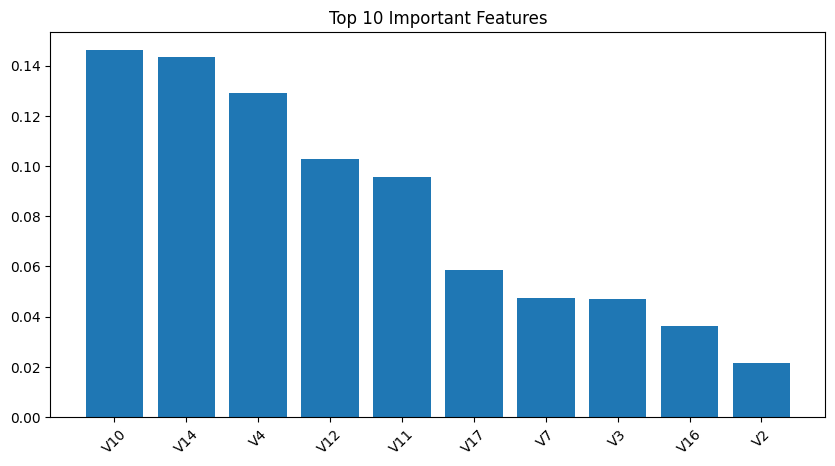

In [9]:
plt.figure(figsize=(10,5))
plt.bar(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.show()

## Random Forest Results Analysis

The Random Forest model achieved a high accuracy of 99.94%. However, accuracy alone is not sufficient for this problem due to the highly imbalanced nature of the dataset.

The recall for fraud detection (Class 1) is 0.83, which means the model successfully identifies 83% of fraudulent transactions. This is important because missing fraud cases (false negatives) can be costly.

The ROC-AUC score of 0.97 indicates excellent overall classification performance.

Feature importance analysis shows that variables such as V10, V14, and V4 contribute most significantly to fraud detection, indicating that the model is learning meaningful patterns from the data.

---

## Discussion and Future Improvements

Although the model performs well, there are still some limitations. A number of fraudulent transactions are not detected, as seen in the false negatives.

The model can be further improved by:

- performing more extensive hyperparameter tuning,
- experimenting with other ensemble methods such as Gradient Boosting,
- using advanced resampling techniques,
- optimizing the model for real-time fraud detection systems.

Overall, Random Forest provides strong performance for this classification problem, especially when combined with techniques like SMOTE to handle class imbalance.